### Week 1 

1. In Coding Quiz 1, you are asked to find the distance of the farthest match in a set.  Is this farthest match distance too far to be a meaningful match?

To answer this question it is important to first understand what matching is in terms of causal inference and what methods we are applying to the data. According to the reading, "Matching is the process of closing back doors between a treatment and an outcome by constructing comparison groups that are similar according to a set of matching variables" (Huntington-Klein, 2022). The need to close these back doors stems from confounders (Z) which can affect both X (treatment) and Y (outcome) making it hard to understand the true impact of the treatment (X). In class we learned about the strong correlation between ice cream sales and shark attacks but this relationship would not be meaningful without understanding the confounding impact of the summer heat which was responsible for the increase in both. The temperature in this instance is creating a back door path between shark attacks and ice cream sales causing a bias which would require a balancing of confounders.

Now that we have identified what matching is in terms of casual inference and the goal of closing back doors it is time to select the approach to matching. From the reading we learned there are two main approaches to matching with either distance matching or propensity score matching. The book states, "Distance matching says'observations are similar if they have similar values of the matching variables'" (Huntingon-Klein, 2022). The latter is defined as, "observations are similar if they were equally likely to be treated, 'in other words have equal treatment propensity'"(Huntingon-Klein, 2022). This was the approach used in coding quiz 1 and the farthest match found was at 0.210217. 

Lastly, before we can answer the question of whether or not this match distance is meaningful or not we must decide if we are selecting matches or constructing a matched weighted sample. The former approach of selecting matches gives everyone in the set an equal weight. On the other hand, a constructed weight match sample would give more weight to matches that were better related and less weight to matches that were farther apart. I would argue that the latter is the better approach in this example and in order to understand the weights it would be important to see the distribution of all matching distances. In this dataset about 75% of matches were within 0.056 making the farthest match of 0.210217 an definitive outlier. I would argue that including this match could introduce bias and I would look to remove it in this instance.     

No AI used


2. In Coding Quiz 1, there are two approaches to matching: 
(A) Picking the best match X = 0 corresponding to each X = 1 using Z values.
(B) Using radius_neighbors to pick all matches X = 0 within a distance of 0.2 of each X = 1.

Invent your own type of matching similar to 1 and 2 (or look one up on the internet), which has a different way to pick the matches in X = 0.  Clearly explain the approach you invented or found.


I found the Optimal Matching approach online through the website https://pmc.ncbi.nlm.nih.gov/articles/PMC2943670/#S10 which I would use to pick the matchines in X = 0. From the above, option (A) is the nearest-neighboar approach to matching where we are looking to match the control to the closest treated unit and then repeat the process so on and so forth. However this approach can leave the matches at the end with farther distances because the closer option was already selected earlier on. With the radius matching in option (B) we are may include weak matches with the distance of .2. For example if we had 90% of the matches within .05 and decided to equally weight the other 10% at .199 just because it was within the .2 limit it does not seem like this would be the best approach. 

The optimal matching approach is different from option (A) and (B) in that it is looking for the best overall pair quality for all possible matches simultaneously. This avoids the problem of going one by one in the greedy approach of the nearsest neighbor by fundamentally looking to minimize total distance in matched pairs; this helps avoid an order bias as well. This approach also avoids giving bad matches equal weights like in the example of the radius nearest neighbors. The optimal matching approach does require more computational effort because it is not as simple as the greedy approach in option (A) and the authors state that its not always a better covariate balance.  

No AI used

### Week 2

1. Invent an example situation that would use fixed effects.

When understanding causal inference or causality it its important to understand the correct causal diagram of what to control for, and to properly measure all the variables we need to control for. This is not always possible and very difficult to identify at times which is why fixed effects is so important. According to the textbook, "Fixed effects is a method of controlling for all variables, whether they're observed or not, as long as they stay constant within some larger category...We just control for the larger category, and in doing so we control for everything that is constant within that category" (Huntington-Klein, 2022).

In DX701 I am working on a policy proposal regarding hate speech on social media where I could theoretically use a fixed effects model to measure. I could attempt to measure the amount of hate speech on twitter before and after Elon Musk purchased the platform. If we apply this situation to the equation the variables would look as follows. The B1 would be the estimated change in hate speech after the purchase of the platform by Musk. The i would be the user account of where the posts were coming from. The t would equal the time periods which could be measured in weeks or months. Alpha_i would be the baseline of hate speech and gamma_t would be the time fixed effects. Lastly there would be a random variable or epsilon that the model could not explain.  

No AI used


2. Write a Python program that performs a bootstrap simulation to find the variance in the mean of the Pareto distribution when different samples are taken.  Explain what you had to do for this.  As you make the full sample size bigger (for the same distribution), what happens to the variance of the mean of the samples?  Does it stay about the same, get smaller, or get bigger?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pareto Distb config
ALPHA = 2.5  # shape
XM = 1.0     # scale
B = 10000    #resamples
N_LIST = [20, 50, 100, 500, 1000]
MASTER_SEED = 7

# RNG 
rng_master = np.random.default_rng(MASTER_SEED)

# Draw Pareto
def pareto(n, rng):
    return XM * (1.0 + rng.pareto(ALPHA, size=n))

# Boot strap 
def manual_bootstrap(sample, B=10000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = len(sample)
    boot_means = np.empty(B, dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)  
        resample = sample[idx]
        boot_means[b] = resample.mean()
    se = boot_means.std(ddof=1)
    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    return se, se**2, ci_low, ci_high, boot_means

rows = []
for n in N_LIST:
    # run samples 
    rng = np.random.default_rng(rng_master.integers(0, 2**32-1))
    sample = pareto(n, rng)
    se, var, ci_low, ci_high, boot_means = manual_bootstrap(sample, B=B, rng=rng)
    rows.append({
        "n": n,
        "sample_mean": float(sample.mean()),
        "boot_SE_mean": float(se),
        "boot_VAR_mean": float(var),
        "CI_low": float(ci_low),
        "CI_high": float(ci_high),
    })

df = pd.DataFrame(rows)

print("Manual bootstrap variance sample mean from Pareto")
print(df.round(4).to_string(index=False))



Manual bootstrap variance sample mean from Pareto
   n  sample_mean  boot_SE_mean  boot_VAR_mean  CI_low  CI_high
  20       1.6461        0.1508         0.0227  1.3761   1.9673
  50       1.7896        0.2872         0.0825  1.4200   2.4195
 100       1.8246        0.3070         0.0942  1.4208   2.5277
 500       1.6941        0.0618         0.0038  1.5816   1.8252
1000       1.6763        0.0356         0.0013  1.6099   1.7500


In class we learned that the Pareto Distribution can be compared to the size of a tree that increases its maximum height every time the sample size is increased. For example if selected 10 trees and the maximum height was four, and then we selected 20 trees the maximum height would be higher than four. It should be noted that its not necessarily the average that is increasing but the maximum observed height. Bootstrap simulation is a technique used to account for the unknown sampling variability of a statistic like mean when the underlying population distribution is unknown. This is a resampling method meaning that certain values in the population might be used more than once and others not used at all. We take the mean of these samples and repeat the process X amount of times to get a distriubtion or spread of the means which gives us our bootstrap distibution. 

To complete this question I first had to set the configuration of the pareto distriubtion of which I would then perform the bootstrap technique on. This is the first part of the code where I set the configution of the pareto making the alpha a 2.5 to ensure there were big outliers or a bigger tail. The next part is the random number generator for each sample size. After this I define the Pareto function along with the manual bootstrap function. Lastly I put the results into rows where I create a dataframe that allowed me to view the sample mean, bootstrap standard error, bootstrap variance, and the confidence intervals for the mean. 

As the full sample size gets bigger the variance starts to get smaller although it did fluctuate before decreasing. This is because even though there are large outliers in the sample there are more samples which decreases the overall variance. I think we saw the fluctuation from the samples at 50 and 100 because a big number or outlier here could move the needle more verseus the larger sample sizes where there are more samples.

Boot strap code sourced from https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html and class notes. AI was used for help with pareto distribution configuration and RNG component of code. 

### Week 3

1. In the event study in Coding Quiz 3, how would we go about testing for a change in the second derivative as well?

We learned that an event study helps us understand whether or not something like a stock price changed due to an event maybe an earnings call or bad news versus a random variation that changed the price. In order to break this technique down we must understand the variables associated in the equation. At t0 we have the event for instance an earnings call when a company releases their quarterly performance and any potential factors for their operation. We must now look at the stock performance before the change at t0 to see if the slope changed this would be the first derivative. The second derivative would be whether or not the curvature changed after t0 or the acceleration of the trend.   

From coding quiz three we could test for a change in the second derivative by looking at that curvature change or acceleration change. To do this we would use Tt = t - t0 or the event which is time centered. After this we would run a piecewise quadratic regression utilizing the pre-event second derivative and the post-event second derivative. If the coefficient (gamma_2) is greater than 0 we could say the trend accelerates and converesly if the gamma_2 is less than 0 we would say the trend decelerates.

No AI used 

2. Create your own scenario that illustrates differences-in-differences. Describe the story behind the data and show whether there is a nonzero treatment effect.

From class we learned that the differences-in-differences method helps predict the signoficance of a treatment by comparing the changes between the treatment group and the control group over time. For my scenario I would like to demonstrate a treatment group of my son and myself playing golf with my son eventually getting lessons. I would score the round of 18 holes of golf for myself and my son to see if there are any trends before giving my son the lessons while I work to afford them. 

For this example we are going to assume my son is older and able to hit the ball a comparable distance to myself with our scores hypothetically being similiar before he goes for lessons. In order for this scenario to be accurate our scores across 18 holes would have to be close to parallel which is also known as parallel trends. If I got my son lessons and there was an improvement in his golf score across 18 holes we could say this is a nonzero treatment effect because his score improved.

No AI used

### Week 4

1. The Coding Quiz gives two options for instrumental variables.  For the second item (dividing the range of W into multiple ranges), explain how you did it, show your code, and discuss any issues you encountered.


In [ ]:

import pandas as pd

# Data frame
df = pd.read_csv("homework_4.1.csv")

# Part 1
means = df.groupby("Z")[["Y", "X"]].mean()
effect = (means.loc[1, "Y"] - means.loc[0, "Y"]) / (means.loc[1, "X"] - means.loc[0, "X"])
print(effect)

# Part 2
df["W_bin"] = pd.cut(df["W"], bins=20)

ratios = []
for wbin, sub in df.groupby("W_bin"):
    if {0, 1}.issubset(sub["Z"].unique()):
        m = sub.groupby("Z")[["Y", "X"]].mean()
        dY = m.loc[1, "Y"] - m.loc[0, "Y"]
        dX = m.loc[1, "X"] - m.loc[0, "X"]
        if dX != 0:
            ratios.append(dY / dX)

effect_conditional = np.mean(ratios)
print(effect_conditional)




1.5618587073955676
1.6166181254784608


/tmp/ipykernel_3101/356169048.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for wbin, sub in df.groupby("W_bin"):


We learned that instrumental variables are useful to estimate relationsips when there can be instances of endogeneity. These are particuarlly useful when there could be hidden bias or issues with reverse causality. When this occurs we need an instrument that affects our independent variable but not necessearily affect the outcome. 

In this example of instrumental variables Z is the instrument, X is the treatment, Y is the outcome, and W is the observed covariates. W would represent the background characteristics that were measured before the treatment. This is why W was binned in the code and the Wald ratio was computed within each bin. Originally I wanted to try and use the statsmodels import to do this code because that is what was talked about in the textbook but I had issues with this. This is the code I wound up with and had to use some help with AI to manage the bins for the W. I also needed to leverage this when trying to get the subgroups in the code. 

AI was used, for the bin technique of W and subgroup

2. Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.


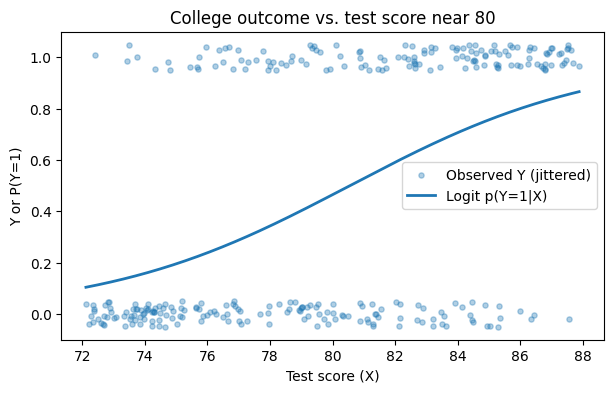

In [15]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Random Data 
rng = np.random.default_rng(42)
n = 300
X = rng.uniform(72, 88, size=n)

# Ground truth 
logit = -20 + 0.25 * X
p = 1 / (1 + np.exp(-logit))
Y = rng.binomial(1, p)

# Logistic regression fit
Xmat = X.reshape(-1, 1)
clf = LogisticRegression(max_iter=1000)
clf.fit(Xmat, Y)

# Grid
lo, hi = X.min(), X.max()
grid = np.linspace(lo, hi, 200).reshape(-1, 1)
p_hat = clf.predict_proba(grid)[:, 1]

# Plot
plt.figure(figsize=(7, 4))
jitter = (rng.random(n) - 0.5) * 0.1
plt.scatter(X, Y + jitter, s=14, alpha=0.35, label="Observed Y (jittered)")
plt.plot(grid.ravel(), p_hat, linewidth=2, label="Logit p(Y=1|X)")

plt.title("College outcome vs. test score near 80")
plt.xlabel("Test score (X)")
plt.ylabel("Y or P(Y=1)")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()


I had to use AI here for the ground truth which I was unfamilar with and the jittering component that helped the plot become readadble